# Workforce Attrition and Department Trends

**Author: Tajamul Khan**

Which departments warrant an employee-experience review?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

HR needs an aggregate view of exits without turning descriptive patterns into individual risk scores.

Calculate annual cohort exit rates and compare department tenure and engagement.

## Data contract and KPI definitions

One row per employee employed at 2025-01-01; exited_2025 flags an exit during 2025. No new hires enter this cohort. Engagement is an illustrative start-of-year score, 1–5. Suppress real-data reporting for small groups; no individual employment decisions are supported.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (1800, 6)


,employee_id,department,tenure_years,engagement_score,annual_salary,exited_2025
0,1,Engineering,10.2,1,93623,0
1,2,Engineering,4.9,3,37766,1
2,3,Operations,10.2,4,121580,0
3,4,Sales,2.8,5,73019,0
4,5,Support,3.6,4,80859,0


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
employee_id,int64,0,1800
department,object,0,5
tenure_years,float64,0,119
engagement_score,int64,0,5
annual_salary,int64,0,1773
exited_2025,int64,0,2


## Action: analysis

Use a fixed beginning-of-year workforce, aggregate exits and document the denominator and ethical limits.

In [3]:
assert df.employee_id.is_unique and df.engagement_score.between(1,5).all()
summary=df.groupby('department').agg(starting_headcount=('employee_id','size'),exits=('exited_2025','sum'),median_tenure=('tenure_years','median'),mean_engagement=('engagement_score','mean'))
summary['cohort_exit_rate_pct']=100*summary.exits/summary.starting_headcount
metrics={'Starting workforce':len(df),'Annual cohort exit rate (%)':100*df.exited_2025.mean(),'Median tenure (years)':df.tenure_years.median()}
chart=summary.cohort_exit_rate_pct; ylabel='Annual cohort exit rate (%)'

## Deep dive: Engagement and observed exits

Compare aggregate exit rates by starting engagement score. This is an association under a simulated data-generating rule, not evidence that changing a score causes retention.

Engineering has the highest observed cohort exit rate (16.18%). Conduct an aggregate employee-experience review; do not score or target individual employees.
Out[4]: 158


,employees,exits,exit_rate_pct
engagement_score,,,
1,364,67,18.41
2,351,72,20.51
3,369,39,10.57
4,363,37,10.19
5,353,43,12.18


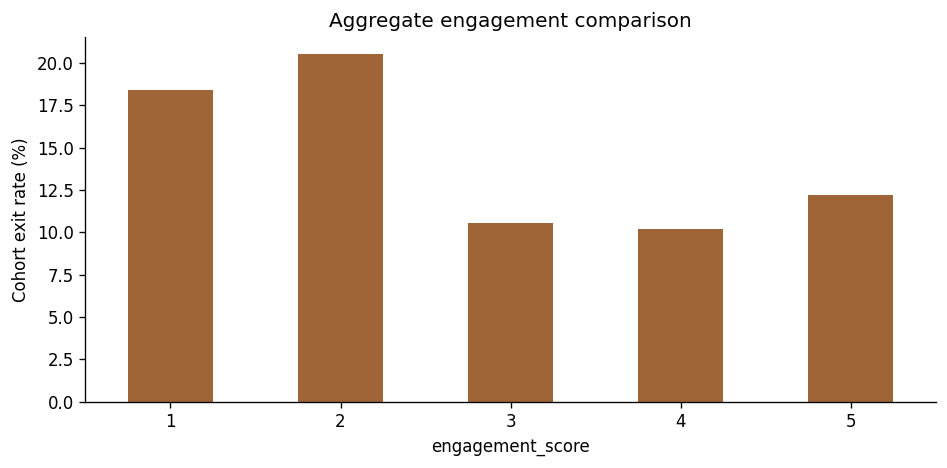

In [4]:

detail=df.groupby('engagement_score').agg(employees=('employee_id','size'),exits=('exited_2025','sum'));detail['exit_rate_pct']=100*detail.exits/detail.employees
display(detail.round(2))
fig,ax=plt.subplots(figsize=(8,4));detail.exit_rate_pct.plot.bar(ax=ax,color='#a06536',rot=0);ax.set_ylabel('Cohort exit rate (%)');ax.set_title('Aggregate engagement comparison');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
worst=summary.cohort_exit_rate_pct.idxmax()
recommendation=f'{worst} has the highest observed cohort exit rate ({summary.loc[worst,"cohort_exit_rate_pct"]:.2f}%). Conduct an aggregate employee-experience review; do not score or target individual employees.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,starting_headcount,exits,median_tenure,mean_engagement,cohort_exit_rate_pct
department,,,,,
Engineering,346,56,6.5,3.0202,16.1850
Finance,356,51,6.1,2.9916,14.3258
Operations,374,45,5.5,3.0267,12.0321
Sales,369,53,5.8,3.0921,14.3631
Support,355,53,6.3,2.8366,14.9296


,value
Starting workforce,1800.000000
Annual cohort exit rate (%),14.333333
Median tenure (years),6.100000


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
sql_result=sql_result.rename(columns={'headcount':'starting_headcount'})
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['starting_headcount', 'exits', 'cohort_exit_rate_pct']


,department,headcount,exits,cohort_exit_rate_pct
0,Engineering,346,56,16.184971
1,Finance,356,51,14.325843
2,Operations,374,45,12.032086
3,Sales,369,53,14.363144
4,Support,355,53,14.929577


## Visual interpretation

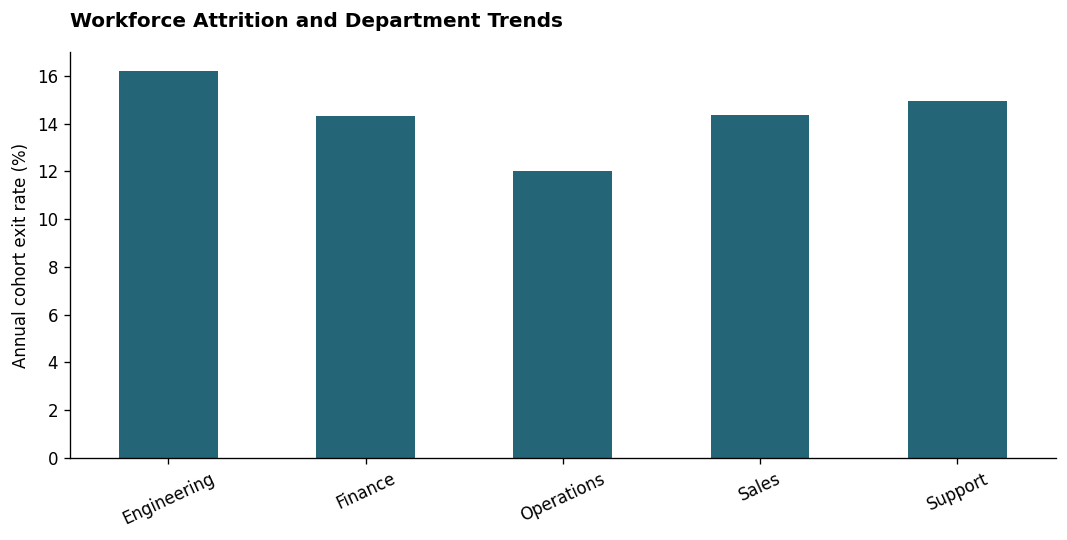

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('Workforce Attrition and Department Trends',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Workforce Attrition and Department Trends</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>Workforce Attrition and Department Trends</h1><p>Which departments warrant an employee-experience review?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>This closed-cohort exit rate is not exits divided by average headcount. Associations do not demonstrate causes; synthetic data contains no real employees.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

This closed-cohort exit rate is not exits divided by average headcount. Associations do not demonstrate causes; synthetic data contains no real employees.

**Next step:** Add monthly employment spells, hiring and average-headcount denominators under appropriate access controls.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.